# S&P 500 Bull & Bear Market Analysis
### Replicating the Vanguard Methodology on `^GSPC` via yfinance

**Methodology (Vanguard, 2026):**
- A **bear market** is defined as a price decline of **more than 20%** from a bull market high.
- A **bull market** is defined as a price increase of **more than 20%** from a bear market low.
- The plotted areas depict cumulative performance from the start of each phase.
- The vertical axis uses a **logarithmic scale**.

**Data source:** Yahoo Finance (`^GSPC`) via `yfinance` — daily closing prices, full history.

> **Note:** Vanguard's original chart uses the MSCI World GBP Index (Bloomberg data, GBP-denominated). 
> This notebook applies the identical analytical framework to the S&P 500 USD index. 
> Results will differ from Vanguard's chart but the methodology is the same.

---

## 0. Install / Import Dependencies

In [4]:
# Install yfinance if not already present
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance', '-q'])

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from IPython.display import display

print(f'yfinance  : {yf.__version__}')
print(f'pandas    : {pd.__version__}')
print(f'matplotlib: {matplotlib.__version__}')

yfinance  : 0.2.62
pandas    : 2.3.0
matplotlib: 3.10.0


## 1. Download S&P 500 Daily Data

In [6]:
# ── Download full history of ^GSPC ────────────────────────────────────────────
print('Downloading ^GSPC (S&P 500) full daily history from Yahoo Finance...')
raw = yf.Ticker('^GSPC').history(period='max', interval='1d', auto_adjust=True)
raw.index = pd.to_datetime(raw.index).tz_localize(None)   # strip timezone
raw = raw[['Close']].dropna().sort_index()

print(f'Date range : {raw.index[0].date()}  →  {raw.index[-1].date()}')
print(f'Trading days: {len(raw):,}')
raw.tail(3)

Date range : 1927-12-30  →  2026-03-06
Trading days: 24,661


,Close
Date,
2026-03-04,6869.500000
2026-03-05,6830.709961
2026-03-06,6740.020020


## 2. Bear / Bull Market Detection Algorithm

The algorithm below faithfully implements the Vanguard definition:

| State | Transition condition | New state |
|-------|---------------------|-----------|
| **Bull** | Close falls **>20%** below the running peak | **Bear confirmed** |
| **Bear** | Close rises **>20%** above the running trough | **Bull confirmed** |

The peak/trough are updated continuously *within* each phase (rolling high/low), so the 20% threshold is always measured from the most recent extreme.

In [8]:
def detect_bull_bear(prices: pd.Series,
                     threshold: float = 0.20) -> pd.DataFrame:
    """
    Detect bull and bear market phases using the Vanguard methodology.

    Parameters
    ----------
    prices    : pd.Series  — daily closing prices (DatetimeIndex)
    threshold : float      — fractional threshold (default 0.20 = 20%)

    Returns
    -------
    pd.DataFrame with columns:
        phase        : 'bull' or 'bear'
        start_date   : first date of the phase
        end_date     : last date of the phase (trough for bear, peak for bull)
        start_price  : index level at start
        end_price    : index level at end (trough / peak)
        cum_return   : cumulative % return over the phase
        duration_days: calendar days
        duration_str : human-readable duration
    """
    prices = prices.copy()
    dates  = prices.index
    vals   = prices.values
    n      = len(vals)

    # ── State machine ─────────────────────────────────────────────────────────
    # Start in bull market from the first data point
    phases     = []          # list of completed phase dicts
    state      = 'bull'      # current state
    phase_start_idx = 0      # index where current phase began
    extreme    = vals[0]     # running peak (bull) or trough (bear)
    extreme_idx = 0

    for i in range(1, n):
        v = vals[i]

        if state == 'bull':
            if v > extreme:
                extreme     = v
                extreme_idx = i
            # Bear confirmed when price drops >threshold from running peak
            if v <= extreme * (1 - threshold):
                # Record completed bull phase (start → peak)
                phases.append({
                    'phase'         : 'bull',
                    'start_idx'     : phase_start_idx,
                    'end_idx'       : extreme_idx,
                    'start_date'    : dates[phase_start_idx],
                    'end_date'      : dates[extreme_idx],
                    'start_price'   : vals[phase_start_idx],
                    'end_price'     : extreme,
                })
                # Transition to bear — new phase starts at the peak
                state           = 'bear'
                phase_start_idx = extreme_idx
                extreme         = vals[extreme_idx]
                extreme_idx     = extreme_idx
                # Update trough from peak to current
                for j in range(extreme_idx, i + 1):
                    if vals[j] < extreme:
                        extreme     = vals[j]
                        extreme_idx = j

        else:  # state == 'bear'
            if v < extreme:
                extreme     = v
                extreme_idx = i
            # Bull confirmed when price rises >threshold from running trough
            if v >= extreme * (1 + threshold):
                # Record completed bear phase (peak → trough)
                phases.append({
                    'phase'         : 'bear',
                    'start_idx'     : phase_start_idx,
                    'end_idx'       : extreme_idx,
                    'start_date'    : dates[phase_start_idx],
                    'end_date'      : dates[extreme_idx],
                    'start_price'   : vals[phase_start_idx],
                    'end_price'     : extreme,
                })
                # Transition to bull — new phase starts at the trough
                state           = 'bull'
                phase_start_idx = extreme_idx
                extreme         = vals[extreme_idx]
                extreme_idx     = extreme_idx
                # Update peak from trough to current
                for j in range(extreme_idx, i + 1):
                    if vals[j] > extreme:
                        extreme     = vals[j]
                        extreme_idx = j

    # ── Append the still-open (current) phase ─────────────────────────────────
    phases.append({
        'phase'         : state,
        'start_idx'     : phase_start_idx,
        'end_idx'       : n - 1,
        'start_date'    : dates[phase_start_idx],
        'end_date'      : dates[n - 1],
        'start_price'   : vals[phase_start_idx],
        'end_price'     : vals[n - 1],
    })

    # ── Build output DataFrame ─────────────────────────────────────────────────
    df = pd.DataFrame(phases)
    df['cum_return_pct'] = (df['end_price'] / df['start_price'] - 1) * 100
    df['duration_days']  = (df['end_date'] - df['start_date']).dt.days

    def fmt_duration(days):
        years  = days // 365
        months = (days % 365) // 30
        parts  = []
        if years  > 0: parts.append(f'{years} year{"s" if years > 1 else ""}')
        if months > 0: parts.append(f'{months} month{"s" if months > 1 else ""}')
        return ' and '.join(parts) if parts else f'{days} days'

    df['duration_str'] = df['duration_days'].apply(fmt_duration)
    df = df.drop(columns=['start_idx', 'end_idx']).reset_index(drop=True)
    return df


phases_df = detect_bull_bear(raw['Close'], threshold=0.20)
print(f'Total phases detected: {len(phases_df)}')
print(f"  Bull phases : {(phases_df['phase'] == 'bull').sum()}")
print(f"  Bear phases : {(phases_df['phase'] == 'bear').sum()}")

Total phases detected: 55
  Bull phases : 28
  Bear phases : 27


## 3. Summary Tables

In [10]:
# ── Format for display ────────────────────────────────────────────────────────
display_df = phases_df[['phase', 'start_date', 'end_date',
                         'start_price', 'end_price',
                         'cum_return_pct', 'duration_days', 'duration_str']].copy()
display_df['start_date']     = display_df['start_date'].dt.strftime('%d %b %Y')
display_df['end_date']       = display_df['end_date'].dt.strftime('%d %b %Y')
display_df['start_price']    = display_df['start_price'].round(2)
display_df['end_price']      = display_df['end_price'].round(2)
display_df['cum_return_pct'] = display_df['cum_return_pct'].round(1).astype(str) + '%'
display_df.columns = ['Phase', 'Start Date', 'End Date',
                      'Start Level', 'End Level',
                      'Cumulative Return', 'Duration (Days)', 'Duration']

# ── Bear markets ──────────────────────────────────────────────────────────────
print('=' * 80)
print('BEAR MARKETS  (>20% decline from bull market high)')
print('=' * 80)
bear_display = display_df[display_df['Phase'] == 'bear'].reset_index(drop=True)
bear_display.index += 1
display(bear_display)

# ── Bull markets ──────────────────────────────────────────────────────────────
print('\n' + '=' * 80)
print('BULL MARKETS  (>20% gain from bear market low)')
print('=' * 80)
bull_display = display_df[display_df['Phase'] == 'bull'].reset_index(drop=True)
bull_display.index += 1
display(bull_display)

BEAR MARKETS  (>20% decline from bull market high)


,Phase,Start Date,End Date,Start Level,End Level,Cumulative Return,Duration (Days),Duration
1,bear,16 Sep 1929,13 Nov 1929,31.86,17.66,-44.6%,58,1 month
2,bear,10 Apr 1930,16 Dec 1930,25.92,14.44,-44.3%,250,8 months
3,bear,24 Feb 1931,02 Jun 1931,18.17,12.20,-32.9%,98,3 months
4,bear,26 Jun 1931,05 Oct 1931,15.35,8.82,-42.5%,101,3 months
5,bear,09 Nov 1931,01 Jun 1932,11.52,4.40,-61.8%,205,6 months
6,bear,07 Sep 1932,27 Feb 1933,9.31,5.53,-40.6%,173,5 months
7,bear,18 Jul 1933,19 Oct 1933,12.20,8.61,-29.4%,93,3 months
8,bear,06 Feb 1934,14 Mar 1935,11.82,8.06,-31.8%,401,1 year and 1 month
9,bear,10 Mar 1937,31 Mar 1938,18.67,8.50,-54.5%,386,1 year
10,bear,10 Oct 1938,11 Apr 1939,13.91,10.42,-25.1%,183,6 months



BULL MARKETS  (>20% gain from bear market low)


,Phase,Start Date,End Date,Start Level,End Level,Cumulative Return,Duration (Days),Duration
1,bull,30 Dec 1927,16 Sep 1929,17.66,31.86,80.4%,626,1 year and 8 months
2,bull,13 Nov 1929,10 Apr 1930,17.66,25.92,46.8%,148,4 months
3,bull,16 Dec 1930,24 Feb 1931,14.44,18.17,25.8%,70,2 months
4,bull,02 Jun 1931,26 Jun 1931,12.20,15.35,25.8%,24,24 days
5,bull,05 Oct 1931,09 Nov 1931,8.82,11.52,30.6%,35,1 month
6,bull,01 Jun 1932,07 Sep 1932,4.40,9.31,111.6%,98,3 months
7,bull,27 Feb 1933,18 Jul 1933,5.53,12.20,120.6%,141,4 months
8,bull,19 Oct 1933,06 Feb 1934,8.61,11.82,37.3%,110,3 months
9,bull,14 Mar 1935,10 Mar 1937,8.06,18.67,131.6%,727,1 year and 12 months
10,bull,31 Mar 1938,10 Oct 1938,8.50,13.91,63.6%,193,6 months


In [11]:
# ── Aggregate statistics ──────────────────────────────────────────────────────
bears = phases_df[phases_df['phase'] == 'bear']
bulls = phases_df[phases_df['phase'] == 'bull']

def avg_duration(days_series):
    avg = days_series.mean()
    years  = int(avg) // 365
    months = (int(avg) % 365) // 30
    parts  = []
    if years  > 0: parts.append(f'{years} yr{"s" if years > 1 else ""}')
    if months > 0: parts.append(f'{months} mo')
    return ' '.join(parts) if parts else f'{int(avg)} days'

stats = pd.DataFrame({
    'Metric': [
        'Count',
        'Avg cumulative return',
        'Median cumulative return',
        'Best / Worst',
        'Avg duration',
        'Median duration',
        'Longest / Shortest',
    ],
    'Bear Markets': [
        len(bears),
        f"{bears['cum_return_pct'].mean():.1f}%",
        f"{bears['cum_return_pct'].median():.1f}%",
        f"{bears['cum_return_pct'].max():.1f}% / {bears['cum_return_pct'].min():.1f}%",
        avg_duration(bears['duration_days']),
        f"{int(bears['duration_days'].median())} days",
        f"{int(bears['duration_days'].max())} / {int(bears['duration_days'].min())} days",
    ],
    'Bull Markets': [
        len(bulls),
        f"{bulls['cum_return_pct'].mean():.1f}%",
        f"{bulls['cum_return_pct'].median():.1f}%",
        f"{bulls['cum_return_pct'].max():.1f}% / {bulls['cum_return_pct'].min():.1f}%",
        avg_duration(bulls['duration_days']),
        f"{int(bulls['duration_days'].median())} days",
        f"{int(bulls['duration_days'].max())} / {int(bulls['duration_days'].min())} days",
    ],
})
print('\nAGGREGATE STATISTICS')
print('=' * 60)
display(stats)


AGGREGATE STATISTICS


,Metric,Bear Markets,Bull Markets
0,Count,27,28
1,Avg cumulative return,-35.1%,112.3%
2,Median cumulative return,-32.9%,80.1%
3,Best / Worst,-20.6% / -61.8%,582.1% / 21.4%
4,Avg duration,9 mo,2 yrs 9 mo
5,Median duration,240 days,638 days
6,Longest / Shortest,630 / 33 days,4494 / 24 days


## 4. Main Chart — Vanguard Style (Bull & Bear Markets Over Time)

Replicates the Vanguard chart structure:
- **Teal/green** shading for bull market phases
- **Grey/muted** shading for bear market phases
- Cumulative return % and duration annotated on each phase
- Logarithmic y-axis
- White background

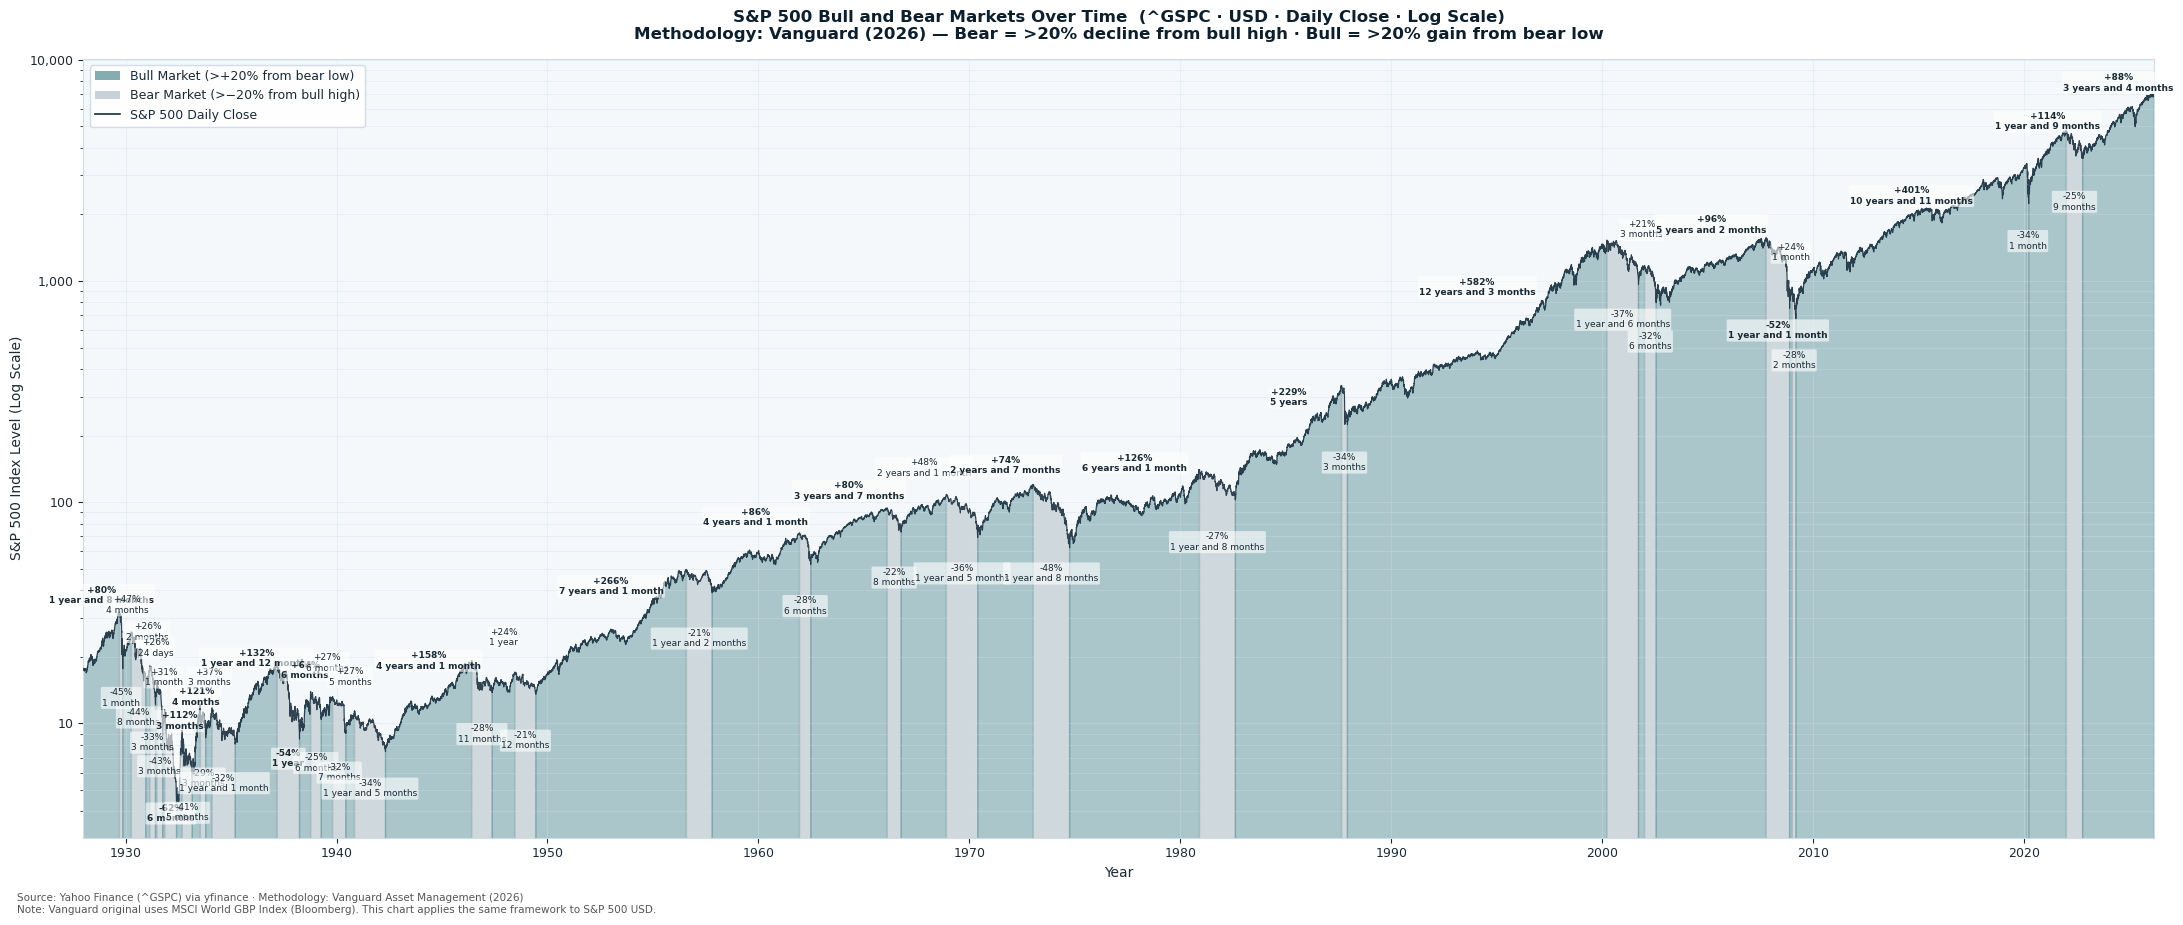

Chart saved: sp500_bull_bear_vanguard_style.png


In [14]:
# ── Color palette ─────────────────────────────────────────────────────────────
COLORS   = ['#74B3CE', '#629EB0', '#5994A1', '#508991', '#345A66',
            '#172A3A', '#004346', '#036257', '#058068']
BG       = 'white'
PANEL    = '#f5f8fa'
GRID     = '#d0dce6'
TEXT     = '#1a2a35'
TITLE    = '#0d1f2d'
BULL_CLR = COLORS[3]   # #508991  mid-teal for bull
BEAR_CLR = '#b0bec5'   # muted blue-grey for bear (matches Vanguard grey)
LINE_CLR = COLORS[5]   # #172A3A  dark navy for the price line
RED      = '#c0392b'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'axes.titleweight' : 'bold',
    'figure.facecolor' : BG,
    'axes.facecolor'   : PANEL,
    'axes.edgecolor'   : GRID,
    'axes.labelcolor'  : TEXT,
    'xtick.color'      : TEXT,
    'ytick.color'      : TEXT,
    'grid.color'       : GRID,
    'grid.linewidth'   : 0.6,
    'text.color'       : TEXT,
})

# ── Build figure ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 9), facecolor=BG)
ax.set_facecolor(PANEL)
for spine in ax.spines.values():
    spine.set_color(GRID)
    spine.set_linewidth(0.8)

# ── Plot price line ───────────────────────────────────────────────────────────
ax.semilogy(raw.index, raw['Close'], color=LINE_CLR,
            linewidth=0.8, alpha=0.85, zorder=3)

# ── Shade phases and annotate ─────────────────────────────────────────────────
for _, row in phases_df.iterrows():
    s  = row['start_date']
    e  = row['end_date']
    sp = row['start_price']
    ep = row['end_price']
    cr = row['cum_return_pct']
    dur = row['duration_str']
    is_bear = (row['phase'] == 'bear')
    color   = BEAR_CLR if is_bear else BULL_CLR
    alpha   = 0.55 if is_bear else 0.45

    # Shade the phase region
    mask = (raw.index >= s) & (raw.index <= e)
    ax.fill_between(raw.index[mask], raw['Close'][mask],
                    alpha=alpha, color=color, zorder=1)

    # Annotate: place label at midpoint of phase
    mid_date = s + (e - s) / 2
    # y position: geometric mean of start/end prices
    mid_price = np.sqrt(sp * ep) * (0.55 if is_bear else 1.6)
    sign = '' if cr < 0 else '+'
    label = f"{sign}{cr:.0f}%\n{dur}"
    fontsize = 6.5
    ax.annotate(
        label,
        xy=(mid_date, mid_price),
        ha='center', va='center',
        fontsize=fontsize,
        color=TEXT,
        fontweight='bold' if abs(cr) > 50 else 'normal',
        zorder=5,
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.6)
    )

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_title(
    'S&P 500 Bull and Bear Markets Over Time  (^GSPC · USD · Daily Close · Log Scale)\n'
    'Methodology: Vanguard (2026) — Bear = >20% decline from bull high · Bull = >20% gain from bear low',
    fontsize=12, fontweight='bold', color=TITLE, pad=14
)
ax.set_ylabel('S&P 500 Index Level (Log Scale)', color=TEXT)
ax.set_xlabel('Year', color=TEXT)
ax.grid(True, which='both', alpha=0.4, color=GRID)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}' if x >= 1 else f'{x:.2f}'
))
ax.set_xlim(raw.index.min(), raw.index.max())

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=BULL_CLR, alpha=0.7, label='Bull Market (>+20% from bear low)'),
    mpatches.Patch(facecolor=BEAR_CLR, alpha=0.7, label='Bear Market (>−20% from bull high)'),
    Line2D([0], [0], color=LINE_CLR, linewidth=1.2, label='S&P 500 Daily Close'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
          facecolor='white', edgecolor=GRID, labelcolor=TEXT, framealpha=0.95)

# ── Source note ───────────────────────────────────────────────────────────────
fig.text(0.01, -0.02,
         'Source: Yahoo Finance (^GSPC) via yfinance · Methodology: Vanguard Asset Management (2026)\n'
         'Note: Vanguard original uses MSCI World GBP Index (Bloomberg). This chart applies the same framework to S&P 500 USD.',
         fontsize=7.5, color='#555555', ha='left')

plt.tight_layout()
plt.savefig('sp500_bull_bear_vanguard_style.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Chart saved: sp500_bull_bear_vanguard_style.png')

## 5. Bear Market Detail Chart — Drawdown & Duration Comparison

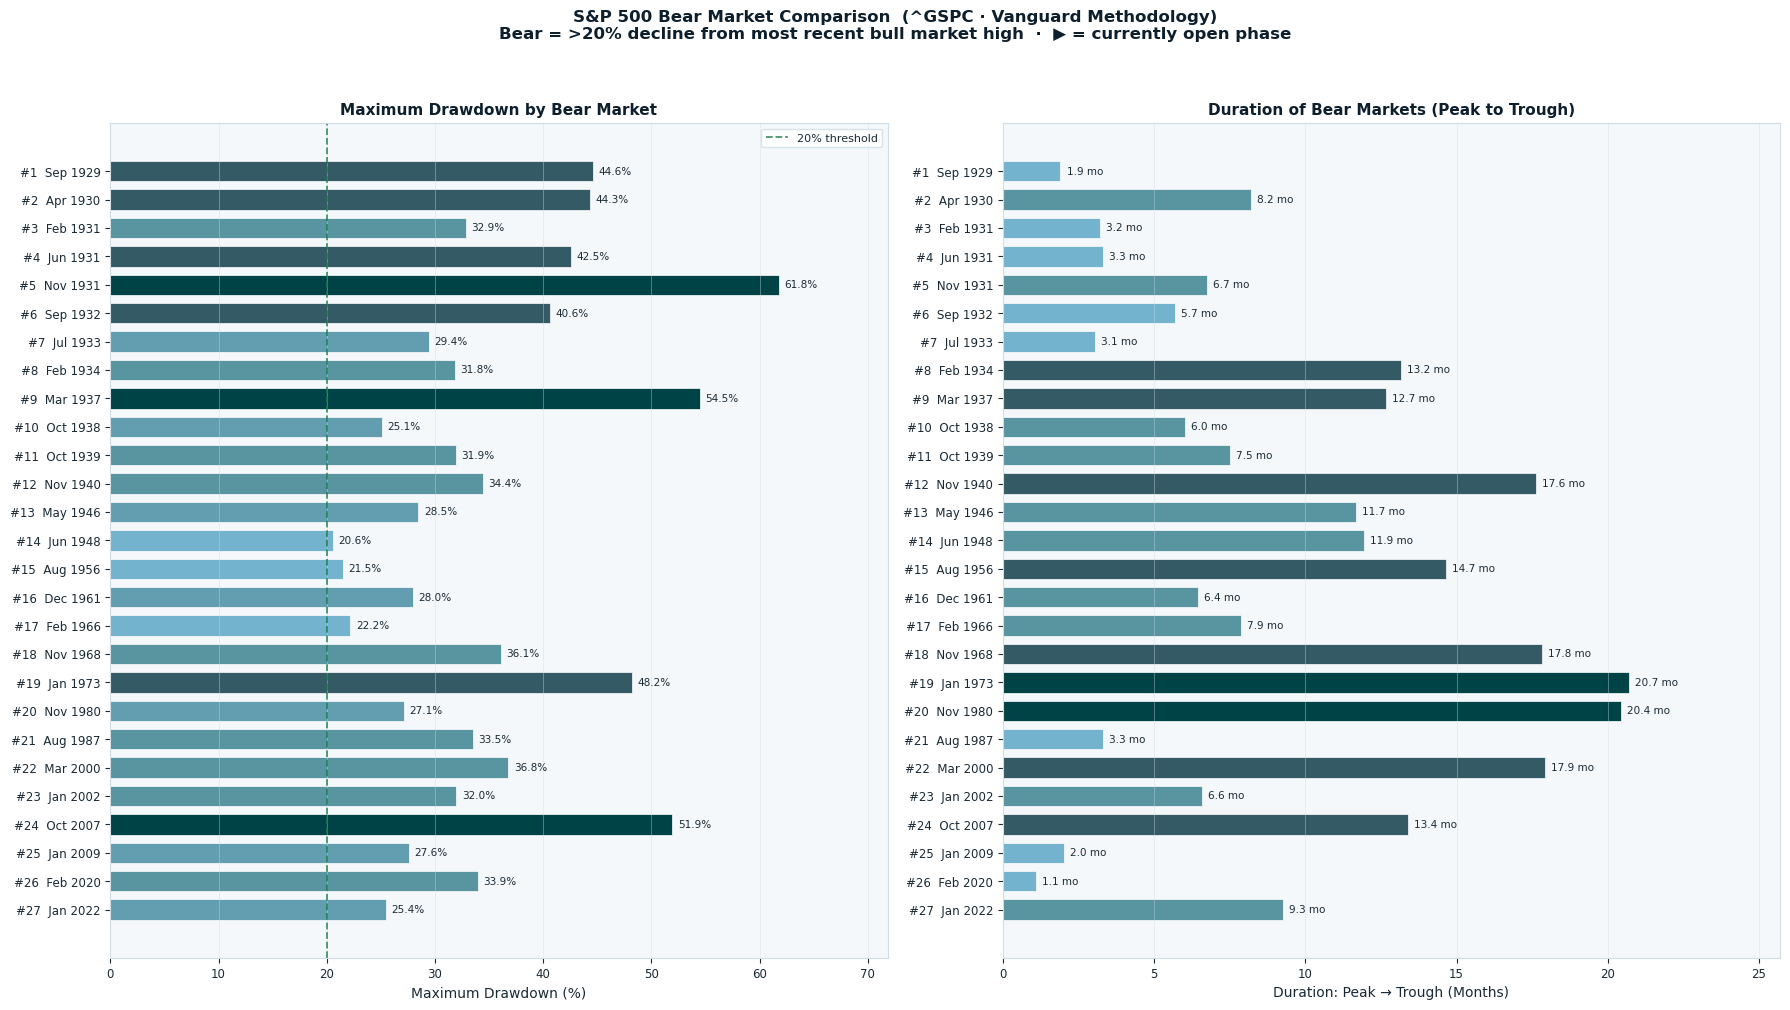

Chart saved: sp500_bear_comparison.png


In [16]:
bears_only = phases_df[phases_df['phase'] == 'bear'].reset_index(drop=True)
# Exclude the currently open phase if it's a bear (incomplete)
# (the last row may be open — flag it)
bears_only['is_open'] = False
last = phases_df.iloc[-1]
if last['phase'] == 'bear':
    bears_only.loc[bears_only.index[-1], 'is_open'] = True

labels    = [f"#{i+1}  {r['start_date'].strftime('%b %Y')}"
             + (" ▶" if r['is_open'] else "")
             for i, r in bears_only.iterrows()]
drawdowns = bears_only['cum_return_pct'].abs().values
durations = bears_only['duration_days'].values / 30.44  # months

def dd_color(d):
    if d >= 50: return COLORS[6]
    if d >= 40: return COLORS[4]
    if d >= 30: return COLORS[2]
    if d >= 25: return COLORS[1]
    return COLORS[0]

def dur_color(d):
    if d >= 18: return COLORS[6]
    if d >= 12: return COLORS[4]
    if d >= 6:  return COLORS[2]
    return COLORS[0]

bar_dd_colors  = [dd_color(d)  for d in drawdowns]
bar_dur_colors = [dur_color(d) for d in durations]

fig2, axes = plt.subplots(1, 2, figsize=(18, max(7, len(labels) * 0.38)), facecolor=BG)
fig2.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(GRID)
        spine.set_linewidth(0.8)
    ax.tick_params(colors=TEXT, labelsize=8.5)

# Drawdown bars
ax3 = axes[0]
bars = ax3.barh(labels, drawdowns, color=bar_dd_colors,
                edgecolor='white', linewidth=0.5, height=0.72)
ax3.axvline(20, color='#1a7a4a', linewidth=1.3, linestyle='--', alpha=0.8,
            label='20% threshold')
ax3.set_xlabel('Maximum Drawdown (%)', fontsize=10, color=TEXT)
ax3.set_title('Maximum Drawdown by Bear Market', fontsize=11,
              fontweight='bold', color=TITLE)
ax3.grid(True, alpha=0.45, color=GRID, axis='x')
ax3.invert_yaxis()
ax3.legend(fontsize=8, facecolor='white', edgecolor=GRID, labelcolor=TEXT)
for bar, val in zip(bars, drawdowns):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', ha='left', color=TEXT, fontsize=7.5)
ax3.set_xlim(0, max(drawdowns) + 10)

# Duration bars
ax4 = axes[1]
bars2 = ax4.barh(labels, durations, color=bar_dur_colors,
                 edgecolor='white', linewidth=0.5, height=0.72)
ax4.set_xlabel('Duration: Peak → Trough (Months)', fontsize=10, color=TEXT)
ax4.set_title('Duration of Bear Markets (Peak to Trough)', fontsize=11,
              fontweight='bold', color=TITLE)
ax4.grid(True, alpha=0.45, color=GRID, axis='x')
ax4.invert_yaxis()
for bar, val in zip(bars2, durations):
    ax4.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f} mo', va='center', ha='left', color=TEXT, fontsize=7.5)
ax4.set_xlim(0, max(durations) + 5)

fig2.suptitle(
    'S&P 500 Bear Market Comparison  (^GSPC · Vanguard Methodology)\n'
    'Bear = >20% decline from most recent bull market high  ·  ▶ = currently open phase',
    color=TITLE, fontsize=12, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('sp500_bear_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Chart saved: sp500_bear_comparison.png')

## 6. Scatter Plot — Bear Market Severity vs. Duration

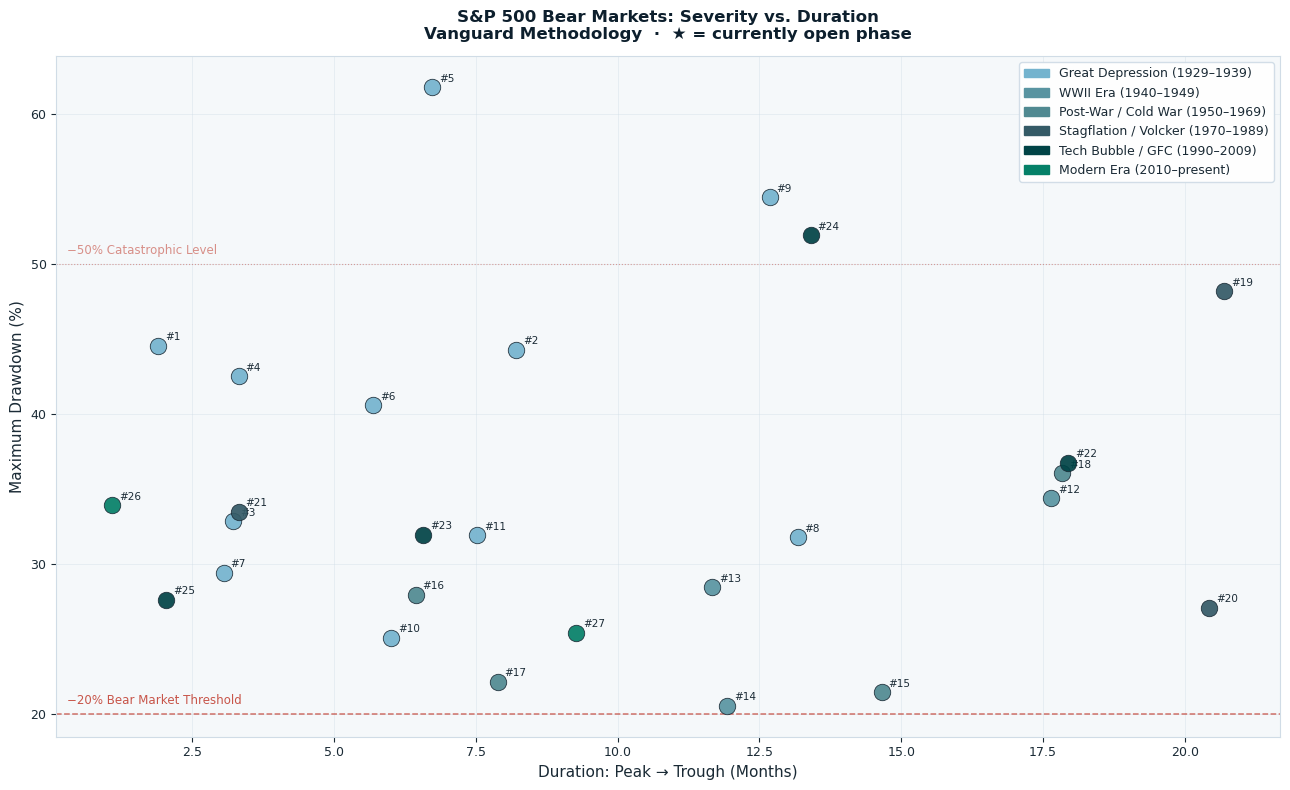

Chart saved: sp500_bear_scatter.png


In [18]:
import matplotlib.patches as mpatches

def era(dt):
    yr = dt.year
    if yr < 1940: return 'Great Depression (1929–1939)', COLORS[0]
    if yr < 1950: return 'WWII Era (1940–1949)',          COLORS[2]
    if yr < 1970: return 'Post-War / Cold War (1950–1969)', COLORS[3]
    if yr < 1990: return 'Stagflation / Volcker (1970–1989)', COLORS[4]
    if yr < 2010: return 'Tech Bubble / GFC (1990–2009)', COLORS[6]
    return          'Modern Era (2010–present)',           COLORS[8]

fig3, ax5 = plt.subplots(figsize=(13, 8), facecolor=BG)
ax5.set_facecolor(PANEL)
for spine in ax5.spines.values():
    spine.set_color(GRID)
    spine.set_linewidth(0.8)
ax5.tick_params(colors=TEXT)

era_handles = {}
for i, row in bears_only.iterrows():
    dd   = abs(row['cum_return_pct'])
    dur  = row['duration_days'] / 30.44
    era_name, color = era(row['start_date'])
    marker = '*' if row['is_open'] else 'o'
    ax5.scatter(dur, dd, s=140, color=color, edgecolors=TEXT,
                linewidths=0.6, zorder=4, alpha=0.92, marker=marker)
    ax5.annotate(f"#{i+1}", xy=(dur, dd), xytext=(5, 4),
                 textcoords='offset points', fontsize=7.5, color=TEXT)
    if era_name not in era_handles:
        era_handles[era_name] = mpatches.Patch(color=color, label=era_name)

ax5.axhline(20, color=RED, linewidth=1.1, linestyle='--', alpha=0.7)
ax5.axhline(50, color=RED, linewidth=0.8, linestyle=':',  alpha=0.45)
ax5.text(0.3, 20.7, '−20% Bear Market Threshold', color=RED, fontsize=8.5, alpha=0.85)
ax5.text(0.3, 50.7, '−50% Catastrophic Level',    color=RED, fontsize=8.5, alpha=0.55)

ax5.set_xlabel('Duration: Peak → Trough (Months)', fontsize=11, color=TEXT)
ax5.set_ylabel('Maximum Drawdown (%)',              fontsize=11, color=TEXT)
ax5.set_title(
    'S&P 500 Bear Markets: Severity vs. Duration\n'
    'Vanguard Methodology  ·  ★ = currently open phase',
    fontsize=12, fontweight='bold', color=TITLE, pad=12
)
ax5.legend(handles=list(era_handles.values()), fontsize=9,
           facecolor='white', edgecolor=GRID, labelcolor=TEXT,
           loc='upper right', framealpha=0.95)
ax5.grid(True, alpha=0.45, color=GRID)

plt.tight_layout()
plt.savefig('sp500_bear_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Chart saved: sp500_bear_scatter.png')

## 7. Drawdown-from-ATH Overlay Chart

Shows the rolling drawdown from the all-time high (a complementary view to the Vanguard chart), with bear market periods highlighted in red.

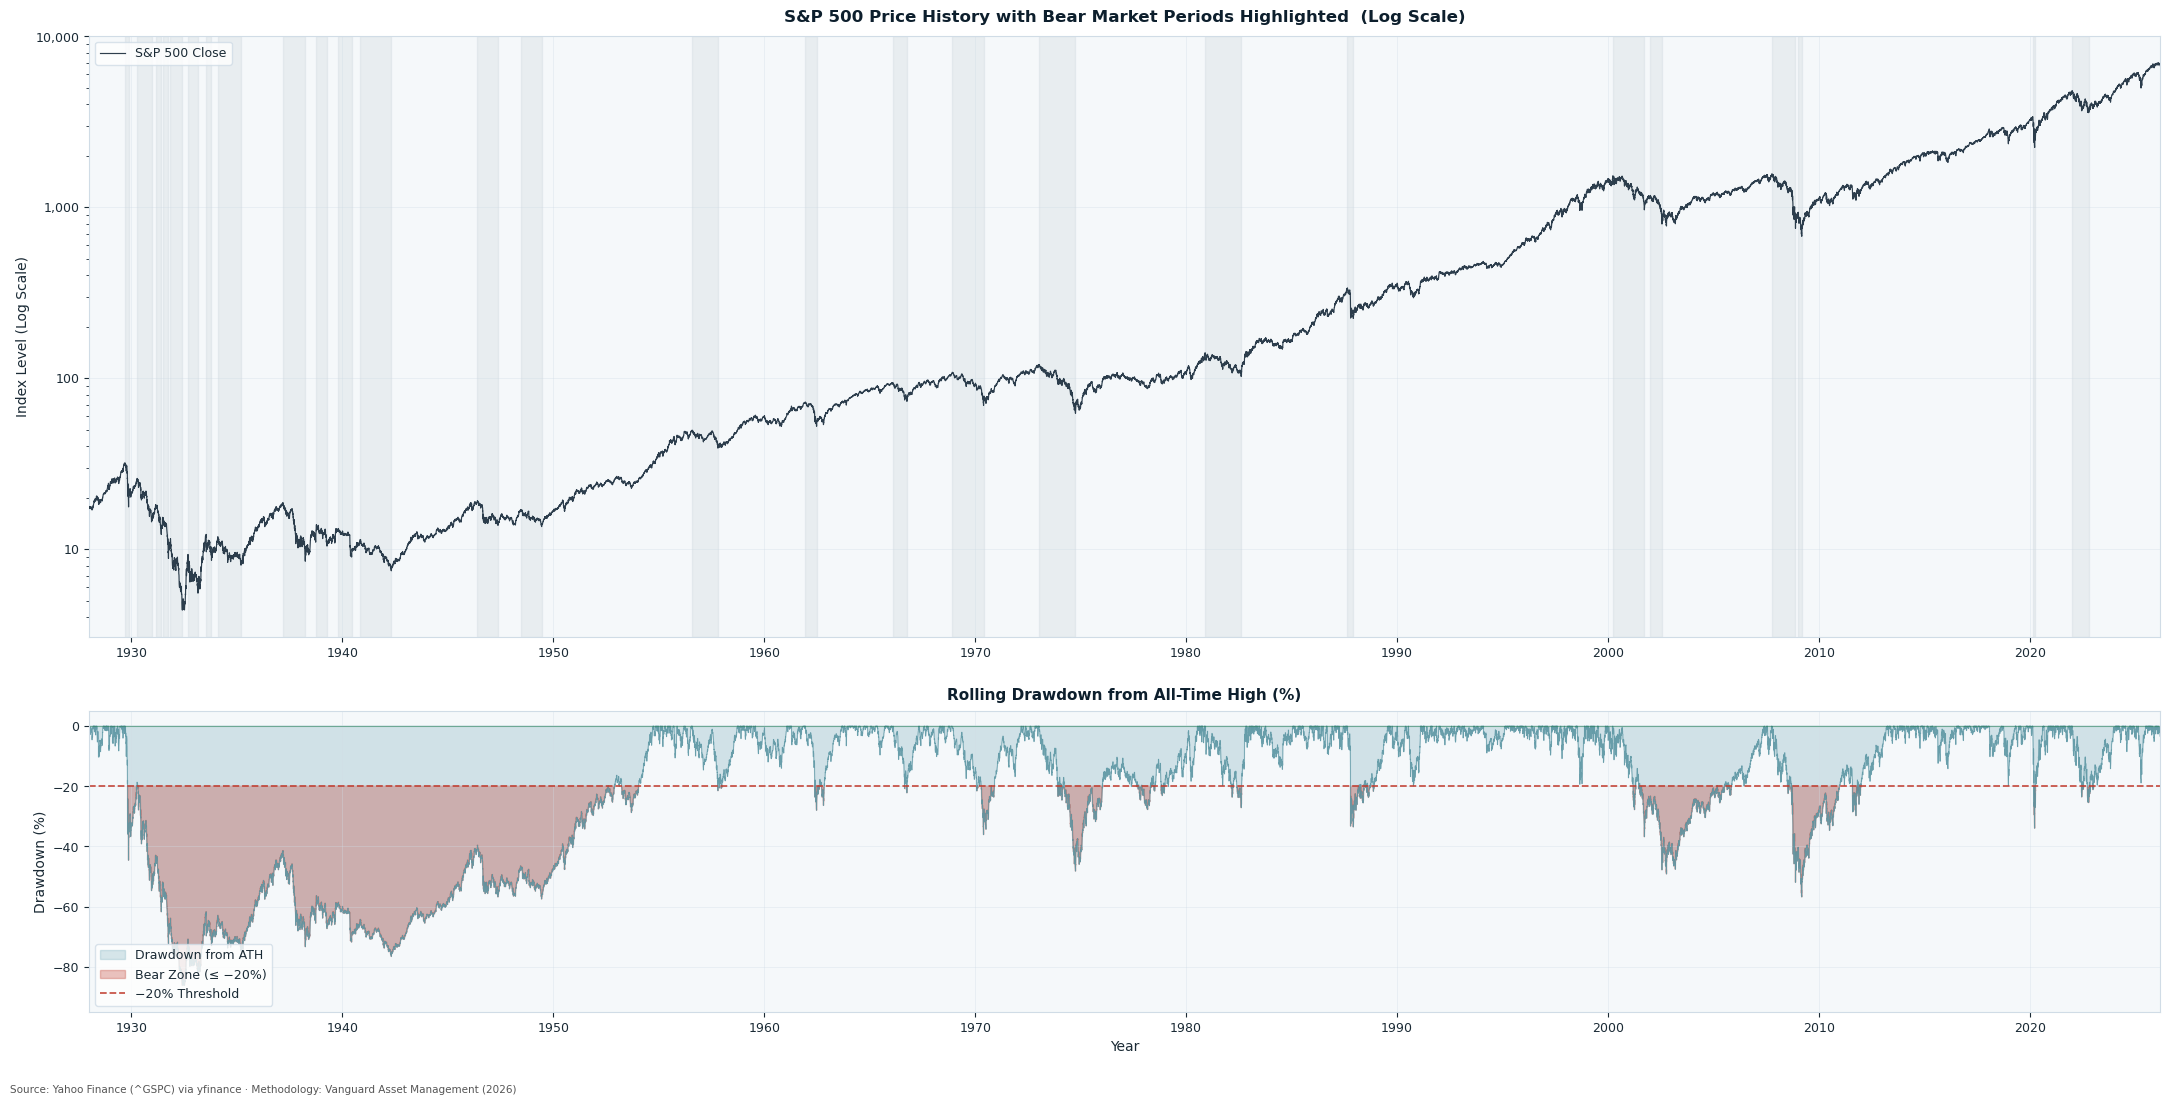

Chart saved: sp500_price_drawdown.png


In [24]:
# ── Compute rolling ATH drawdown ──────────────────────────────────────────────
raw['ATH']      = raw['Close'].cummax()
raw['Drawdown'] = (raw['Close'] - raw['ATH']) / raw['ATH'] * 100

fig4, (ax6, ax7) = plt.subplots(2, 1, figsize=(22, 11),
                                  gridspec_kw={'height_ratios': [2, 1]},
                                  facecolor=BG)
fig4.patch.set_facecolor(BG)

for ax in (ax6, ax7):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(GRID)
        spine.set_linewidth(0.8)
    ax.tick_params(colors=TEXT)

# Top: price with bear shading
ax6.semilogy(raw.index, raw['Close'], color=LINE_CLR, linewidth=0.85,
             alpha=0.9, zorder=3, label='S&P 500 Close')
for _, row in bears_only.iterrows():
    ax6.axvspan(row['start_date'], row['end_date'],
                alpha=0.18, color=BEAR_CLR, zorder=0)

ax6.set_title(
    'S&P 500 Price History with Bear Market Periods Highlighted  (Log Scale)',
    fontsize=12, fontweight='bold', color=TITLE, pad=10
)
ax6.set_ylabel('Index Level (Log Scale)', color=TEXT)
ax6.legend(loc='upper left', fontsize=9, facecolor='white',
           edgecolor=GRID, labelcolor=TEXT)
ax6.grid(True, alpha=0.4, color=GRID)
ax6.set_xlim(raw.index.min(), raw.index.max())
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}' if x >= 1 else f'{x:.2f}'
))

# Bottom: drawdown
ax7.fill_between(raw.index, raw['Drawdown'], 0,
                 where=(raw['Drawdown'] < 0),
                 color=COLORS[1], alpha=0.25, label='Drawdown from ATH')
ax7.fill_between(raw.index, raw['Drawdown'], -20,
                 where=(raw['Drawdown'] <= -20),
                 color=RED, alpha=0.30, label='Bear Zone (≤ −20%)')
ax7.plot(raw.index, raw['Drawdown'], color=COLORS[2], linewidth=0.55, alpha=0.85)
ax7.axhline(-20, color=RED, linewidth=1.3, linestyle='--', alpha=0.85,
            label='−20% Threshold')
ax7.axhline(0,   color='#1a7a4a', linewidth=0.8, alpha=0.5)
ax7.set_title('Rolling Drawdown from All-Time High (%)',
              fontsize=11, fontweight='bold', color=TITLE, pad=8)
ax7.set_ylabel('Drawdown (%)', color=TEXT)
ax7.set_xlabel('Year', color=TEXT)
ax7.legend(loc='lower left', fontsize=9, facecolor='white',
           edgecolor=GRID, labelcolor=TEXT)
ax7.grid(True, alpha=0.4, color=GRID)
ax7.set_xlim(raw.index.min(), raw.index.max())
ax7.set_ylim(-95, 5)

fig4.text(0.01, -0.01,
          'Source: Yahoo Finance (^GSPC) via yfinance · Methodology: Vanguard Asset Management (2026)',
          fontsize=7.5, color='#555555')
plt.tight_layout(pad=2.0)
plt.savefig('sp500_price_drawdown.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Chart saved: sp500_price_drawdown.png')

## 8. Bull vs. Bear Duration Distribution

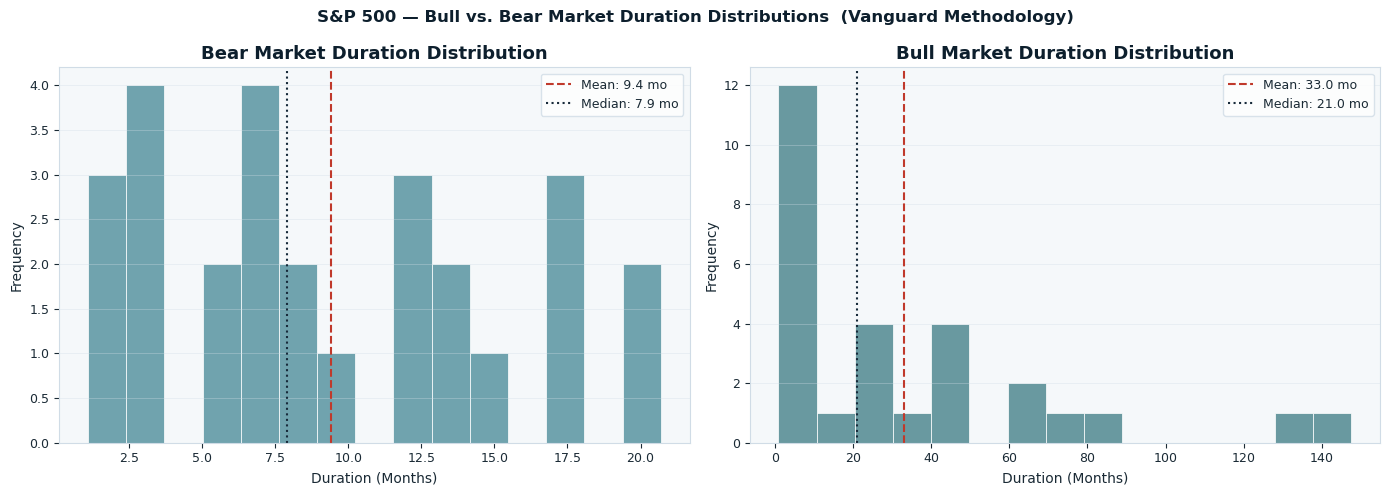

Chart saved: sp500_duration_distributions.png


In [26]:
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig5.patch.set_facecolor(BG)

for ax in axes5:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(GRID)
        spine.set_linewidth(0.8)
    ax.tick_params(colors=TEXT)

bear_months = bears['duration_days'] / 30.44
bull_months = bulls['duration_days'] / 30.44

axes5[0].hist(bear_months, bins=15, color=COLORS[2], edgecolor='white',
              linewidth=0.6, alpha=0.85)
axes5[0].axvline(bear_months.mean(), color=RED, linewidth=1.5, linestyle='--',
                 label=f'Mean: {bear_months.mean():.1f} mo')
axes5[0].axvline(bear_months.median(), color=COLORS[5], linewidth=1.5, linestyle=':',
                 label=f'Median: {bear_months.median():.1f} mo')
axes5[0].set_title('Bear Market Duration Distribution', fontweight='bold', color=TITLE)
axes5[0].set_xlabel('Duration (Months)', color=TEXT)
axes5[0].set_ylabel('Frequency', color=TEXT)
axes5[0].legend(fontsize=9, facecolor='white', edgecolor=GRID, labelcolor=TEXT)
axes5[0].grid(True, alpha=0.4, color=GRID, axis='y')

axes5[1].hist(bull_months, bins=15, color=COLORS[3], edgecolor='white',
              linewidth=0.6, alpha=0.85)
axes5[1].axvline(bull_months.mean(), color=RED, linewidth=1.5, linestyle='--',
                 label=f'Mean: {bull_months.mean():.1f} mo')
axes5[1].axvline(bull_months.median(), color=COLORS[5], linewidth=1.5, linestyle=':',
                 label=f'Median: {bull_months.median():.1f} mo')
axes5[1].set_title('Bull Market Duration Distribution', fontweight='bold', color=TITLE)
axes5[1].set_xlabel('Duration (Months)', color=TEXT)
axes5[1].set_ylabel('Frequency', color=TEXT)
axes5[1].legend(fontsize=9, facecolor='white', edgecolor=GRID, labelcolor=TEXT)
axes5[1].grid(True, alpha=0.4, color=GRID, axis='y')

fig5.suptitle('S&P 500 — Bull vs. Bear Market Duration Distributions  (Vanguard Methodology)',
              fontsize=12, fontweight='bold', color=TITLE)
plt.tight_layout()
plt.savefig('sp500_duration_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Chart saved: sp500_duration_distributions.png')

---
## Methodology & Sources

| Item | Detail |
|------|--------|
| **Data source** | Yahoo Finance (`^GSPC`) via `yfinance` Python library |
| **Index** | S&P 500 Composite Index (USD, daily closing prices) |
| **History** | 1927-12-30 → present (max available via yfinance) |
| **Price adjustment** | `auto_adjust=True` (split-adjusted) |
| **Bear definition** | >20% decline from the most recent bull market high |
| **Bull definition** | >20% gain from the most recent bear market low |
| **Phase end** | Bear ends at the trough; bull ends at the peak |
| **Methodology source** | Vanguard Asset Management (2026), *Bull and Bear Markets Over Time* |
| **Original Vanguard index** | MSCI World GBP Index (Bloomberg, GBP-denominated) |
| **Pre-1957 caveat** | S&P 500 in current 500-stock form launched March 1957; earlier data uses predecessor indices (S&P 90/425) back-filled by Yahoo Finance |

**Reference:** Vanguard Asset Management, Limited. *Bull and Bear Markets Over Time.* 2026. `02/26_330_UK_5138019`.